In [20]:
import matplotlib.pyplot as plt
from scipy import stats
import bisect
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [29]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

class ResponseSimulator:

    def __init__(self, n: int, esp: float):
        self.esp = esp
        self.n = n

    def calc_best_query_num(self):
        INF = 10**9

        best_cost = INF
        best_q = 1
        for q in range(1, 15):
            cost = self.inference_score(q)
            if cost < best_cost:
                best_q = q
                best_cost = cost
        return best_q, best_cost
            
    def inference_correct_prob(self, query_num):

        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        SAMPLE_N = 10 ** 5
        model_vs = query_num # 代表正解値。なんでもよいはず。

        mu, sigma = calc_mu_sigma(query_num, self.esp, model_vs)
        rng = np.random.default_rng()
        samples = rng.normal(mu, sigma, SAMPLE_N)

        correct_cnt = 0
        for sample in samples:
            if model_vs == bisect.bisect_left(mu_mids, max(0, round(sample))):
                correct_cnt += 1
        prob = correct_cnt / SAMPLE_N
        return prob

    def inference_score(self, query_num:int):
        if query_num == 1:
            return self.n**2
        grid_size = self.n**2
        prob = self.inference_correct_prob(query_num) ** grid_size
        # print(prob, self.esp, query_num)
        expected_cost = (grid_size / np.sqrt(query_num)) + grid_size * (1-prob)
        return expected_cost
    
    def env_setting(self, query_num: int):
        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        self.query_num = query_num
        self.mu_mids = mu_mids

    def calc_true_val_from_response(self, resp_val):
        return bisect.bisect_left(self.mu_mids, resp_val)

In [30]:
N = 20
ESP = 0.01
response_simulator = ResponseSimulator(n=N, esp=ESP)
print(response_simulator.inference_correct_prob(query_num=16))
# calc_mu_sigma(k = 16, e = ESP, vs = 5)

0.0


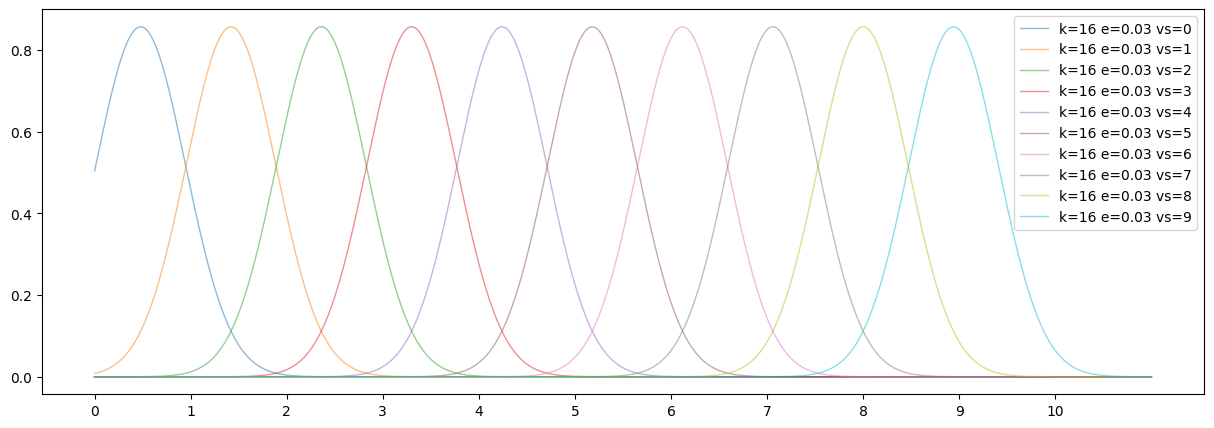

In [33]:
k = 16
e = 0.03

plt.figure(figsize=(15, 5))
x_max = 11
X = np.linspace(0, x_max, 1000)

for vs in range(10):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)

    norm_pdf = stats.norm.pdf(x=X, loc=mu, scale=sigma)
    norm_pdf = norm_pdf
    norm_pdf_max = np.max(norm_pdf)

    plt.plot(X, norm_pdf, lw=1, alpha=0.5, label=f"k={k} e={e} vs={vs}")
    plt.legend()
    plt.xticks(np.arange(0, x_max, 1))


plt.show()